<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Genesis004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


GENESIS004 — Harmonic Radius ℓ = 40
Harmonic ratio at ℓ = 40: 0.0003


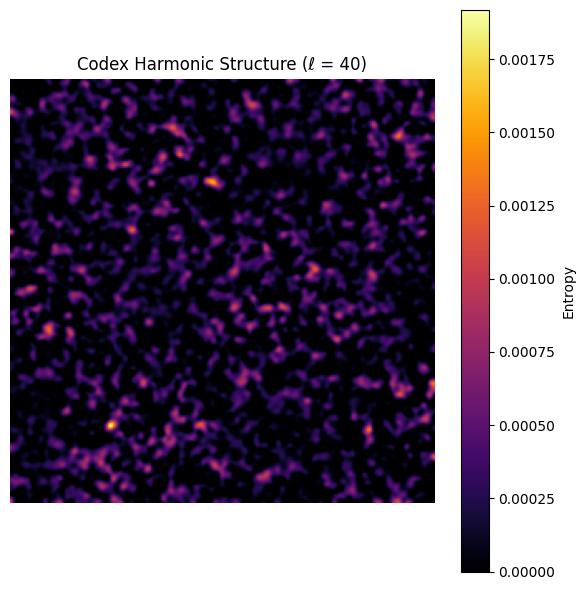


GENESIS004 — Harmonic Radius ℓ = 60
Harmonic ratio at ℓ = 60: 0.0005


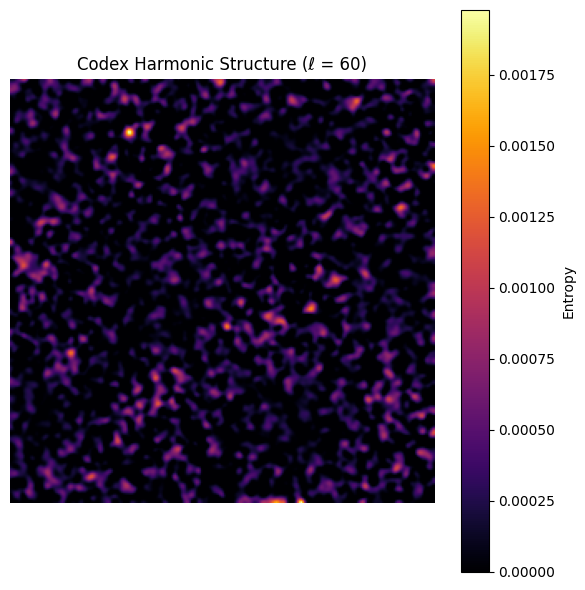


GENESIS004 — Harmonic Radius ℓ = 80
Harmonic ratio at ℓ = 80: 0.0016


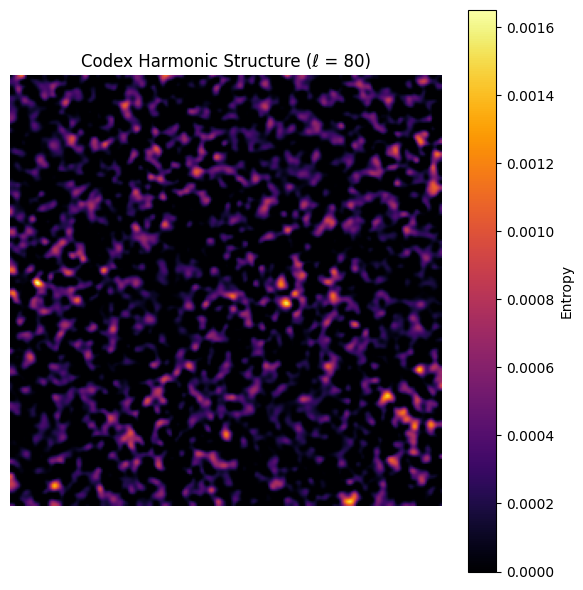


GENESIS004 — Harmonic Radius ℓ = 100
Harmonic ratio at ℓ = 100: 0.0128


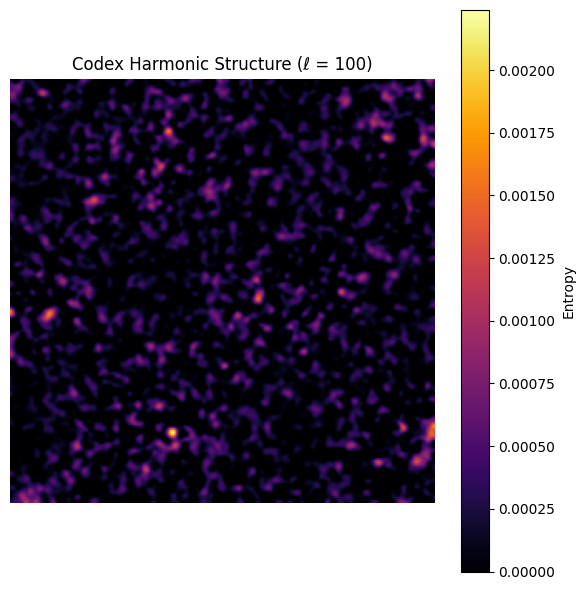


GENESIS004 — Harmonic Radius ℓ = 120
Harmonic ratio at ℓ = 120: 0.1579


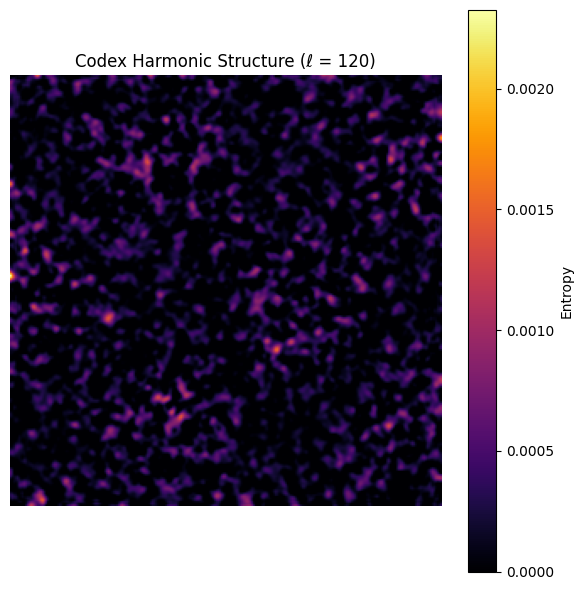


GENESIS004 — Harmonic Radius ℓ = 140
Harmonic ratio at ℓ = 140: 4.2539


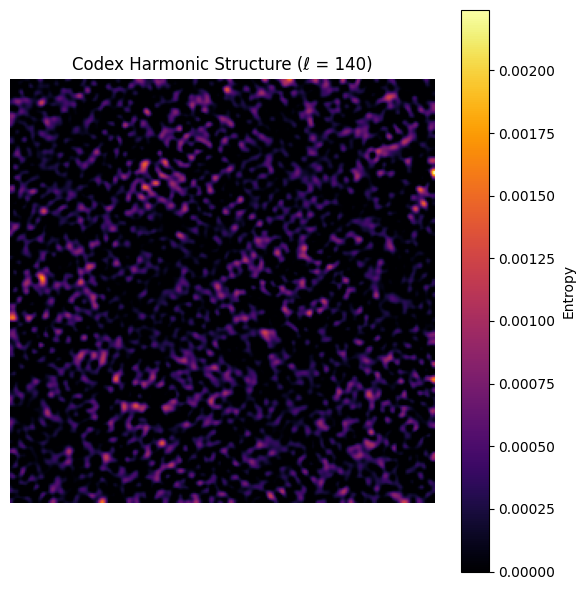

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import laplace, gaussian_filter
from scipy.fft import fft2, ifft2

# ============================================================
# INITIAL CONDITIONS
# ============================================================

def seed_entropy_2d(N, asymmetry_scale=0.2):
    x = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, x)
    asymmetry = np.sin(5 * X) * np.cos(5 * Y)
    noise = np.random.uniform(0.45, 0.55, (N, N))
    return np.clip(noise + asymmetry_scale * asymmetry, 0.0, 1.0)

def seed_curvature_2d(N, noise_level=0.05):
    return np.random.normal(0, noise_level, (N, N))

def seed_memory_2d(S, C):
    return np.clip(np.abs(C) * S, 0.0, 1.0)

# ============================================================
# MEMORY & CURVATURE EVOLUTION
# ============================================================

def update_memory_2d(S, C, M, mu=0.08, decay=0.01, dt=0.01):
    imprint = np.abs(C) * S
    dM_dt = mu * imprint - decay * M
    return np.clip(M + dt * dM_dt, 0.0, 1.0)

def evolve_curvature_2d(S, C, alpha=0.08, beta=0.03, xi=0.01, dt=0.01):
    lap_S = laplace(S)
    lap_C = laplace(C)
    dC_dt = alpha * lap_S - beta * C + xi * lap_C
    return C + dt * dC_dt

def retrieve_restoring_force_2d(C, M, smooth_sigma=1.5):
    raw = C * M
    smoothed = gaussian_filter(raw, sigma=smooth_sigma)
    return np.clip(smoothed, -1.0, 2.0)

# ============================================================
# FIELD-MASS SATURATION FEEDBACK
# ============================================================

def amplify_codex_harmonic_2d(S, R, target_radius=100, G_crit=4.0):
    fft_R = fft2(R)
    center = np.array(R.shape) // 2
    y, x = np.ogrid[:R.shape[0], :R.shape[1]]
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    mask = (r >= target_radius - 2) & (r <= target_radius + 2)

    S_mean = np.mean(S)
    S_max = S.shape[0] * S.shape[1] * 2.0
    G_sat = G_crit * (1.0 - S_mean / S_max)
    G_sat = max(G_sat, 0.0)

    fft_R[mask] *= G_sat
    return np.real(ifft2(fft_R))

# ============================================================
# ENTROPY EVOLUTION
# ============================================================

def evolve_entropy_2d(S, R, steps=20000, dt=0.01, G_crit=4.0, target_radius=100):
    for _ in range(steps):
        lap_S = laplace(S)
        R_amplified = amplify_codex_harmonic_2d(S, R, target_radius=target_radius, G_crit=G_crit)
        S += dt * (lap_S + R_amplified - S)
        S = np.clip(S, 0.0, 2.0)
    return S

# ============================================================
# ANALYSIS
# ============================================================

def measure_harmonic_2d(S, target_radius=100):
    fft = fft2(S)
    power = np.abs(fft)**2
    center = np.array(S.shape) // 2
    y, x = np.ogrid[:S.shape[0], :S.shape[1]]
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    mask = (r >= target_radius - 2) & (r <= target_radius + 2)
    codex_power = np.mean(power[mask]) if np.any(mask) else 0
    total_power = np.mean(power)
    return codex_power / total_power if total_power > 0 else 0

def plot_entropy_2d(S, title="Codex Harmonic Structure"):
    plt.figure(figsize=(6, 6))
    plt.imshow(S, cmap='inferno', origin='lower')
    plt.colorbar(label='Entropy')
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# ============================================================
# RUN SWEEP
# ============================================================

def run_genesis_004_sweep(N=256, G_crit=4.0, radii=[40, 60, 80, 100, 120, 140]):
    for ℓ in radii:
        print(f"\nGENESIS004 — Harmonic Radius ℓ = {ℓ}")
        S = seed_entropy_2d(N)
        C = seed_curvature_2d(N)
        M = seed_memory_2d(S, C)

        for _ in range(100):
            C = evolve_curvature_2d(S, C)
            M = update_memory_2d(S, C, M)

        R_emergent = retrieve_restoring_force_2d(C, M)
        S_final = evolve_entropy_2d(S, R_emergent, steps=20000, G_crit=G_crit, target_radius=ℓ)
        harmonic_ratio = measure_harmonic_2d(S_final, target_radius=ℓ)
        print(f"Harmonic ratio at ℓ = {ℓ}: {harmonic_ratio:.4f}")
        plot_entropy_2d(S_final, title=f"Codex Harmonic Structure (ℓ = {ℓ})")

if __name__ == "__main__":
    run_genesis_004_sweep()
